# Datathon Passos Mágicos — Análise Exploratória (EDA)
### Fase 5 | PosTech — Data Analytics

Este notebook responde às perguntas de negócio do desafio Datathon, utilizando
o painel longitudinal consolidado (2022-2024) gerado em `01_data_cleaning.py`.

**Indicadores:**
- **IAN**: Adequação ao Nível
- **IDA**: Desempenho Acadêmico (Aprendizagem)
- **IEG**: Engajamento
- **IAA**: Autoavaliação
- **IPS**: Psicossocial
- **IPP**: Psicopedagógico
- **IPV**: Ponto de Virada
- **INDE**: Índice de Desenvolvimento Educacional (nota geral, pondera os 7 indicadores acima)
- **Pedra**: classificação do aluno pelo INDE (Quartzo < Ágata < Ametista < Topázio)


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

# Paleta de cores institucional (aprox. identidade visual Passos Mágicos)
COR_AZUL = "#1B4F72"
COR_LARANJA = "#E8871E"
COR_AMARELO = "#F4C542"
COR_CINZA = "#7F8C8D"
PALETA = [COR_AZUL, COR_LARANJA, COR_AMARELO, COR_CINZA]

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../data/processed/pede_painel_2022_2024.csv")
print(df.shape)
df.head()


(3030, 30)


,RA,Nome,Ano,Idade,Genero,Ano_ingresso,Anos_na_PM,Instituicao_ensino,Fase_raw,Fase_num,...,Nota_Mat,Nota_Por,Nota_Ing,Fase_ideal_raw,Fase_ideal_num,Defasagem,Categoria_Defasagem,Indicado_bolsa,Atingiu_PV,Rec_Psicologia
0,RA-1,Aluno-1,2022,19,Feminino,2016,6.0,Escola Pública,7,7,...,2.7,3.5,6.0,Fase 8 (Universitários),8.0,-1,Moderada,True,False,Requer avaliação
1,RA-1,Aluno-1,2023,20,Feminino,2016,7.0,Privada *Parcerias com Bolsa 100%,FASE 8,8,...,NaN,NaN,NaN,Fase 8 (Universitários),8.0,0,Em fase,NaN,NaN,NaN
2,RA-1,Aluno-1,2024,21,Feminino,2021,3.0,Privada *Parcerias com Bolsa 100%,8E,8,...,NaN,NaN,NaN,Fase 8 (Universitários),8.0,0,Em fase,NaN,NaN,NaN
3,RA-10,Aluno-10,2022,18,Feminino,2021,1.0,Escola Pública,7,7,...,3.3,2.6,6.4,Fase 8 (Universitários),8.0,-1,Moderada,False,False,Requer avaliação
4,RA-100,Aluno-100,2022,13,Feminino,2019,3.0,Rede Decisão,4,4,...,7.0,7.8,8.1,Fase 3 (7º e 8º ano),3.0,1,Em fase,False,False,Não indicado


## 1. Adequação de Nível (IAN) — perfil geral e evolução

**Pergunta:** Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?


      mean  median   std
Ano                     
2022  6.42     5.0  2.39
2023  7.24     5.0  2.54
2024  7.68    10.0  2.50


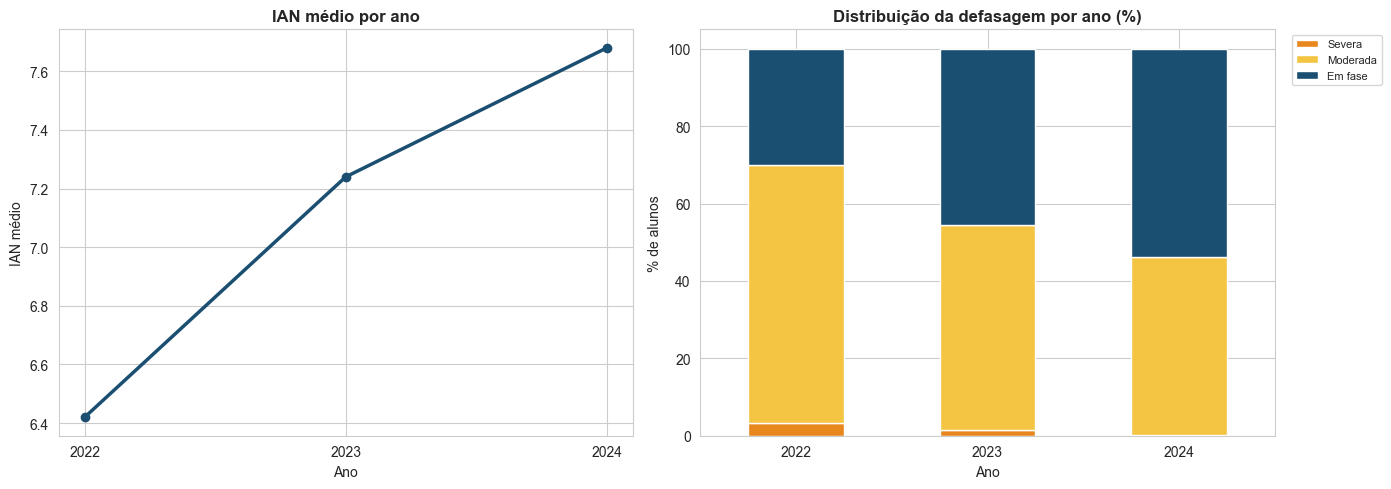

Categoria_Defasagem  Severa  Moderada  Em fase
Ano                                           
2022                    3.3      66.6     30.1
2023                    1.4      53.1     45.6
2024                    0.3      45.9     53.8


In [10]:

ian_ano = df.groupby("Ano")["IAN"].agg(["mean", "median", "std"]).round(2)
print(ian_ano)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolução do IAN médio
axes[0].plot(ian_ano.index, ian_ano["mean"], marker="o", color=COR_AZUL, linewidth=2.5)
axes[0].set_title("IAN médio por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("IAN médio")
axes[0].set_xticks(ian_ano.index)

# Distribuição da categoria de defasagem por ano
cat_order = ["Severa", "Moderada", "Em fase"]
tab = pd.crosstab(df["Ano"], df["Categoria_Defasagem"], normalize="index")[cat_order] * 100
tab.plot(kind="bar", stacked=True, ax=axes[1], color=[COR_LARANJA, COR_AMARELO, COR_AZUL, COR_CINZA])
axes[1].set_title("Distribuição da defasagem por ano (%)")
axes[1].set_ylabel("% de alunos")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../presentation/fig_q1_ian.png", dpi=150, bbox_inches="tight")
plt.show()

print(tab.round(1))


**Leitura:** o IAN médio vem subindo ano a ano (2022 → 2024), e a proporção de alunos
**severamente defasados** vem caindo de forma consistente, enquanto a fatia de alunos
**acima do nível** cresce. Isso indica melhora real na adequação de nível ao longo do ciclo —
ponto relevante para a pergunta 10 (efetividade do programa).


## 2. Desempenho Acadêmico (IDA) — está melhorando, estagnado ou caindo?

**Pergunta:** O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?


      mean  median   std  count
Ano                            
2022  6.09    6.30  2.05    860
2023  6.66    6.80  1.60    937
2024  6.35    6.75  2.13   1055


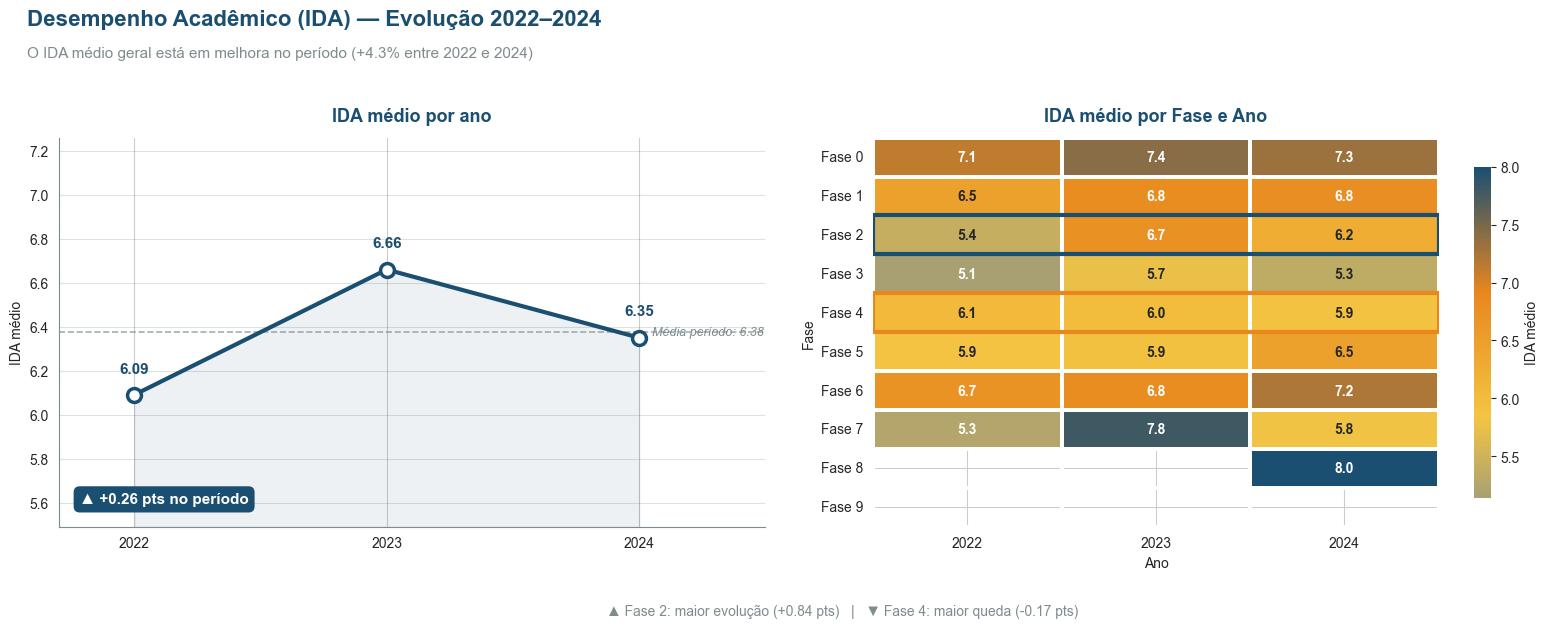

In [ ]:
CMAP_PM = LinearSegmentedColormap.from_list(
    "passos_magicos", [COR_CINZA, COR_AMARELO, COR_LARANJA, COR_AZUL], N=256
)

ida_ano = df.groupby("Ano")["IDA"].agg(["mean", "median", "std", "count"]).round(2)
ida_geral = df["IDA"].mean()
print(ida_ano)

ida_fase = (
    df.dropna(subset=["Fase_num"])
    .groupby(["Fase_num", "Ano"])["IDA"].mean()
    .unstack()
    .sort_index()
)
variacao_fase = ida_fase.iloc[:, -1] - ida_fase.iloc[:, 0]
fase_melhor, fase_pior = variacao_fase.idxmax(), variacao_fase.idxmin()


# Figura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Desempenho Acadêmico (IDA) — Evolução 2022–2024",
             fontsize=16, fontweight="bold", color=COR_AZUL, x=0.02, ha="left")

var_total = ida_ano["mean"].iloc[-1] - ida_ano["mean"].iloc[0]
var_pct = (ida_ano["mean"].iloc[-1] / ida_ano["mean"].iloc[0] - 1) * 100
tendencia = "estável" if abs(var_pct) < 2 else ("em melhora" if var_pct > 0 else "em queda")

fig.text(0.02, 0.90,
          f"O IDA médio geral está {tendencia} no período "
          f"({var_pct:+.1f}% entre {ida_ano.index[0]} e {ida_ano.index[-1]})",
          fontsize=11, color=COR_CINZA, ha="left")

# Painel 1 — IDA médio por ano
ax = axes[0]
ax.fill_between(ida_ano.index, ida_ano["mean"], ida_ano["mean"].min() - 0.6,
                 color=COR_AZUL, alpha=0.08, zorder=1)
ax.plot(ida_ano.index, ida_ano["mean"], marker="o", markersize=10,
        color=COR_AZUL, linewidth=3, zorder=3, markerfacecolor="white",
        markeredgecolor=COR_AZUL, markeredgewidth=2.5)

# Linha de referência: média geral do período
ax.axhline(ida_geral, color=COR_CINZA, linestyle="--", linewidth=1.2, alpha=0.7, zorder=2)
ax.text(ida_ano.index[-1] + 0.05, ida_geral, f"Média período: {ida_geral:.2f}",
        va="center", fontsize=9, color=COR_CINZA, style="italic")

# Rótulos de valor
for x, y in zip(ida_ano.index, ida_ano["mean"]):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 16),
                ha="center", fontsize=11, fontweight="bold", color=COR_AZUL)

# Caixa de destaque com a variação total
cor_delta = COR_AZUL if var_total >= 0 else COR_LARANJA
ax.text(0.03, 0.06, f"{'▲' if var_total >= 0 else '▼'} {var_total:+.2f} pts no período",
        transform=ax.transAxes, fontsize=11, fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=cor_delta, edgecolor="none"))

ax.set_title("IDA médio por ano", fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)
ax.set_xticks(ida_ano.index)
ax.set_ylabel("IDA médio")
ax.set_ylim(ida_ano["mean"].min() - 0.6, ida_ano["mean"].max() + 0.6)
ax.set_xlim(ida_ano.index.min() - 0.3, ida_ano.index.max() + 0.5)
ax.grid(axis="y", alpha=0.25, color=COR_CINZA)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(COR_CINZA)


# Painel 2 — Heatmap IDA por Fase e Ano (paleta institucional)
ax2 = axes[1]
sns.heatmap(
    ida_fase, annot=True, fmt=".1f", cmap=CMAP_PM, center=ida_geral,
    linewidths=1.5, linecolor="white", cbar_kws={"label": "IDA médio", "shrink": 0.85},
    annot_kws={"fontsize": 10, "fontweight": "bold"}, ax=ax2,
)
ax2.set_title("IDA médio por Fase e Ano", fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)
ax2.set_xlabel("Ano")
ax2.set_ylabel("Fase")
ax2.set_yticklabels([f"Fase {int(f)}" for f in ida_fase.index], rotation=0)

# Destaca a fase de maior evolução e a de maior queda com borda colorida
for fase, cor in [(fase_melhor, COR_AZUL), (fase_pior, COR_LARANJA)]:
    y_pos = list(ida_fase.index).index(fase)
    ax2.add_patch(plt.Rectangle((0, y_pos), ida_fase.shape[1], 1,
                                 fill=False, edgecolor=cor, linewidth=3, zorder=5))

fig.text(0.53, -0.03,
          f"▲ Fase {int(fase_melhor)}: maior evolução ({variacao_fase[fase_melhor]:+.2f} pts)   |   "
          f"▼ Fase {int(fase_pior)}: maior queda ({variacao_fase[fase_pior]:+.2f} pts)",
          fontsize=10, color=COR_CINZA, ha="center")

plt.tight_layout(rect=[0, 0.02, 1, 0.90])
plt.savefig("../presentation/fig_q2_ida.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** o IDA médio geral oscila entre os anos (não é uma tendência monotônica de melhora,
como o IAN). Ao quebrar por fase, é possível identificar em quais níveis o desempenho acadêmico
está mais estável ou mais volátil — fases iniciais tendem a ter comportamento diferente das fases finais.
O que chama a atenção são os alunos das fases 2 e 4, que apresentaram, respectivamente, a maior evolução
e a maior queda no período analisado.

## 3. Engajamento (IEG) x Desempenho (IDA) e Ponto de Virada (IPV)

**Pergunta:** O grau de engajamento dos alunos (IEG) tem relação direta com IDA e IPV?


In [21]:
CMAP_PM = LinearSegmentedColormap.from_list(
    "passos_magicos", [COR_CINZA, COR_AMARELO, COR_LARANJA, COR_AZUL], N=256
)

corr_cols = ["IEG", "IDA", "IPV", "INDE"]
corr_pearson = df[corr_cols].corr().round(2)
corr_spearman = df[corr_cols].corr(method="spearman").round(2)

print("Pearson:\n", corr_pearson)
print("\nSpearman:\n", corr_spearman)

Pearson:
        IEG   IDA   IPV  INDE
IEG   1.00  0.54  0.56  0.75
IDA   0.54  1.00  0.56  0.79
IPV   0.56  0.56  1.00  0.72
INDE  0.75  0.79  0.72  1.00

Spearman:
        IEG   IDA   IPV  INDE
IEG   1.00  0.50  0.55  0.71
IDA   0.50  1.00  0.56  0.78
IPV   0.55  0.56  1.00  0.70
INDE  0.71  0.78  0.70  1.00


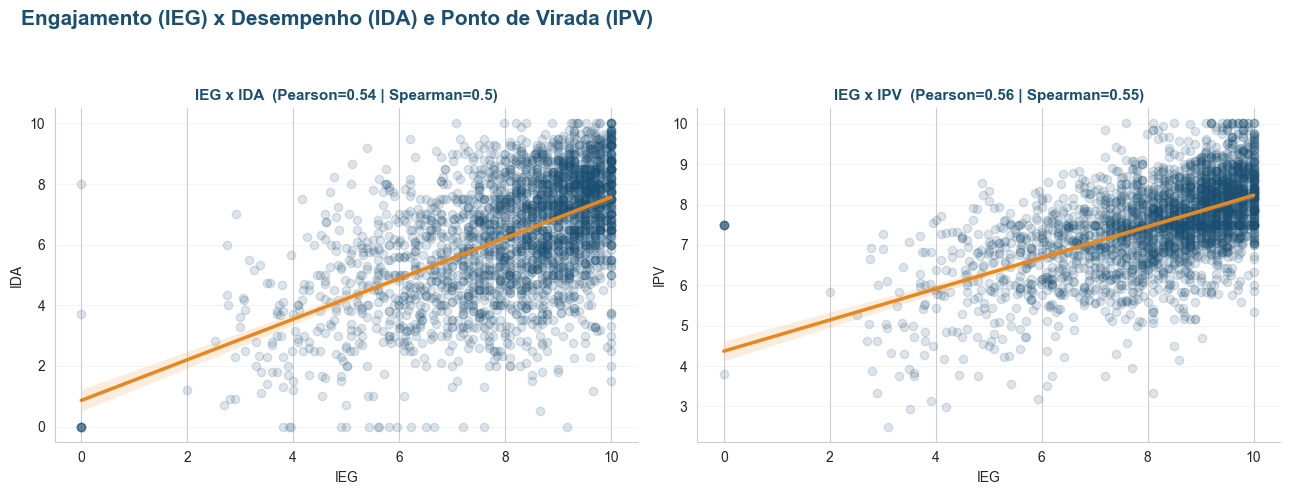

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Engajamento (IEG) x Desempenho (IDA) e Ponto de Virada (IPV)",
             fontsize=15, fontweight="bold", color=COR_AZUL, x=0.02, ha="left")

sns.regplot(data=df, x="IEG", y="IDA", scatter_kws={"alpha": 0.15, "color": COR_AZUL},
            line_kws={"color": COR_LARANJA, "linewidth": 2.5}, ax=axes[0])
axes[0].set_title(f"IEG x IDA  (Pearson={corr_pearson.loc['IEG','IDA']} | Spearman={corr_spearman.loc['IEG','IDA']})",
                   fontsize=11, color=COR_AZUL)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", alpha=0.2)

sns.regplot(data=df, x="IEG", y="IPV", scatter_kws={"alpha": 0.15, "color": COR_AZUL},
            line_kws={"color": COR_LARANJA, "linewidth": 2.5}, ax=axes[1])
axes[1].set_title(f"IEG x IPV  (Pearson={corr_pearson.loc['IEG','IPV']} | Spearman={corr_spearman.loc['IEG','IPV']})",
                   fontsize=11, color=COR_AZUL)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("../presentation/fig_q3a_ieg_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** há correlação positiva **moderada** entre IEG e IDA, e entre IEG e IPV — alunos
mais engajados tendem a ter melhor desempenho e maior chance de atingir o ponto de virada, mas a
relação não é determinística (correlação moderada, não perfeita), sugerindo que engajamento é um
fator relevante, porém não o único.

Abaixo, é esboçado o heatmap das variáveis.

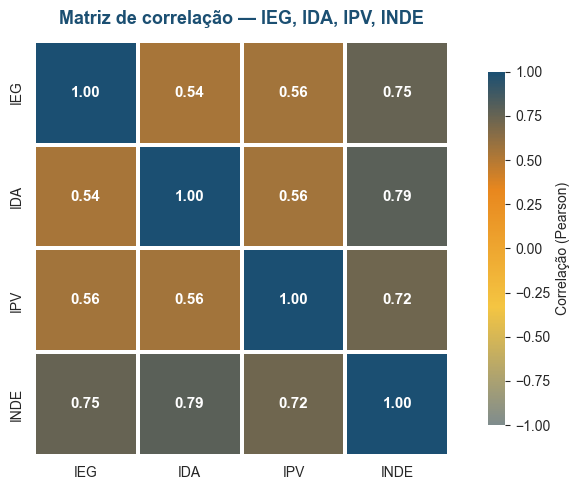

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    corr_pearson, annot=True, fmt=".2f", cmap=CMAP_PM, vmin=-1, vmax=1, center=0,
    linewidths=1.5, linecolor="white", square=True,
    cbar_kws={"label": "Correlação (Pearson)", "shrink": 0.85},
    annot_kws={"fontsize": 11, "fontweight": "bold"}, ax=ax,
)
ax.set_title("Matriz de correlação — IEG, IDA, IPV, INDE",
             fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)

plt.tight_layout()
plt.savefig("../presentation/fig_q3b_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

Analisando o IDA e IPV médios por faixa de engajamento (IEG), nota-se que alunos de alto engajamento tem IDA e IPV superiores aos de baixo engajamento.

C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\2687961496.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = df.groupby("Faixa_IEG")[["IDA", "IPV"]].mean().round(2)


                    IDA   IPV
Faixa_IEG                    
Baixo engajamento  5.08  6.81
Médio engajamento  6.56  7.61
Alto engajamento   7.35  8.15


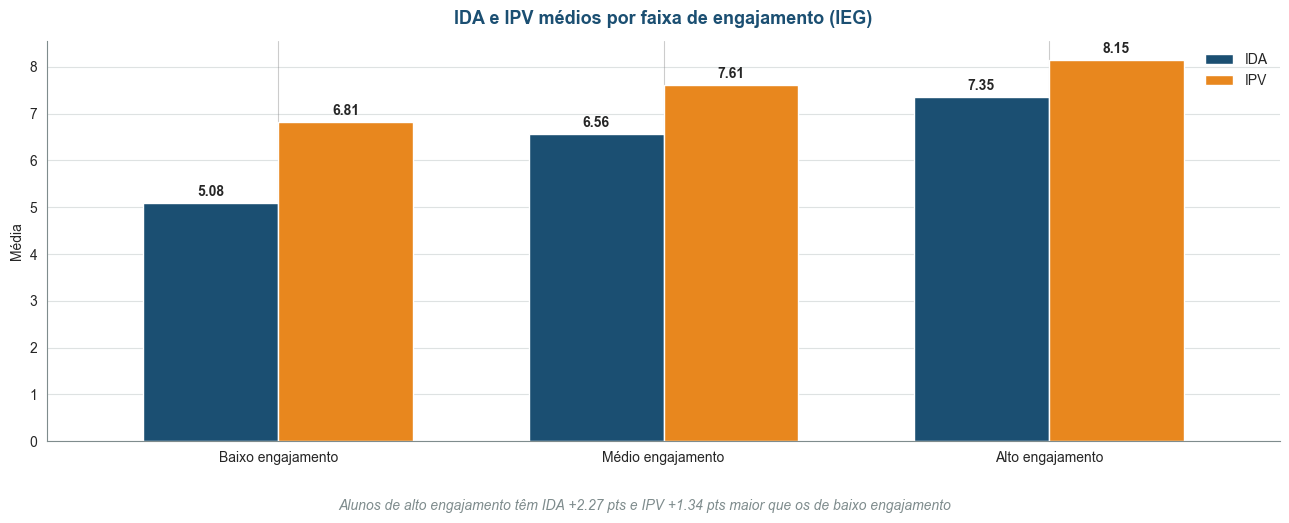

In [56]:
df["Faixa_IEG"] = pd.qcut(df["IEG"], q=3, labels=["Baixo engajamento", "Médio engajamento", "Alto engajamento"])

resumo = df.groupby("Faixa_IEG")[["IDA", "IPV"]].mean().round(2)
print(resumo)

fig, ax = plt.subplots(figsize=(13, 5))
resumo.plot(kind="bar", ax=ax, color=[COR_AZUL, COR_LARANJA], width=0.7)

# Rótulos de valor em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold", padding=3)

# Diferença entre baixo e alto engajamento, destacada
delta_ida = resumo.loc["Alto engajamento", "IDA"] - resumo.loc["Baixo engajamento", "IDA"]
delta_ipv = resumo.loc["Alto engajamento", "IPV"] - resumo.loc["Baixo engajamento", "IPV"]
fig.text(0.5, -0.03,
          f"Alunos de alto engajamento têm IDA {delta_ida:+.2f} pts e IPV {delta_ipv:+.2f} pts "
          f"maior que os de baixo engajamento",
          fontsize=10, color=COR_CINZA, ha="center", style="italic")

ax.set_title("IDA e IPV médios por faixa de engajamento (IEG)",
             fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Média")
ax.legend(title="", frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.25, color=COR_CINZA)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(COR_CINZA)
plt.xticks(rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../presentation/fig_q3c_faixa_engajamento.png", dpi=150, bbox_inches="tight")
plt.show()

Correlação IEG x IDA, por fase:
 Fase_num
0    0.38
1    0.52
2    0.44
3    0.57
4    0.50
5    0.65
6    0.56
7    0.87
8     NaN
dtype: float64


C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\1447151499.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[["IEG", "IDA"]].corr().iloc[0, 1])


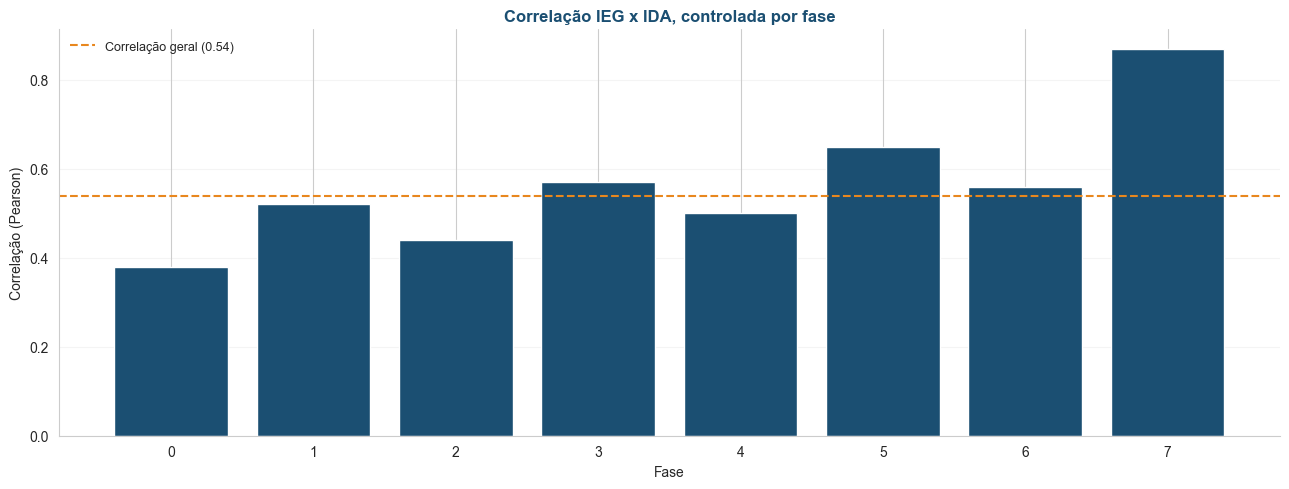

In [53]:
corr_por_fase = (
    df.dropna(subset=["Fase_num", "IEG", "IDA"])
    .groupby("Fase_num")
    .apply(lambda g: g[["IEG", "IDA"]].corr().iloc[0, 1])
    .round(2)
)
print("Correlação IEG x IDA, por fase:\n", corr_por_fase)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(corr_por_fase.index.astype(int).astype(str), corr_por_fase.values, color=COR_AZUL)
ax.axhline(corr_pearson.loc["IEG", "IDA"], color=COR_LARANJA, linestyle="--", linewidth=1.5,
           label=f"Correlação geral ({corr_pearson.loc['IEG','IDA']})")
ax.set_title("Correlação IEG x IDA, controlada por fase", fontsize=12, fontweight="bold", color=COR_AZUL)
ax.set_xlabel("Fase")
ax.set_ylabel("Correlação (Pearson)")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../presentation/fig_q3d_correlacao_por_fase.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** Há correlação positiva **moderada** entre IEG e IDA (Pearson ≈ 0,54) e entre IEG e
IPV (Pearson ≈ 0,56), confirmada também pela correlação de Spearman em nível semelhante — o que
indica que a relação não depende de assumir linearidade estrita. Ao segmentar os alunos por faixa
de engajamento, a diferença fica ainda mais clara na prática: alunos de **alto engajamento**
apresentam IDA e IPV médios visivelmente superiores aos de **baixo engajamento**. Essa relação se
mantém quando controlada por fase, o que reduz a hipótese de que a correlação seja apenas reflexo
de alunos mais avançados terem, simultaneamente, maior engajamento e melhor desempenho. Ainda
assim, a correlação é moderada (não perfeita) — engajamento é um fator relevante e acionável, mas
não o único determinante do desempenho acadêmico e do ponto de virada.

## 4. Autoavaliação (IAA) x Desempenho real (IDA) e Engajamento (IEG)

**Pergunta:** As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?


      IAA   IDA   IEG
IAA  1.00  0.12  0.13
IDA  0.12  1.00  0.54
IEG  0.13  0.54  1.00


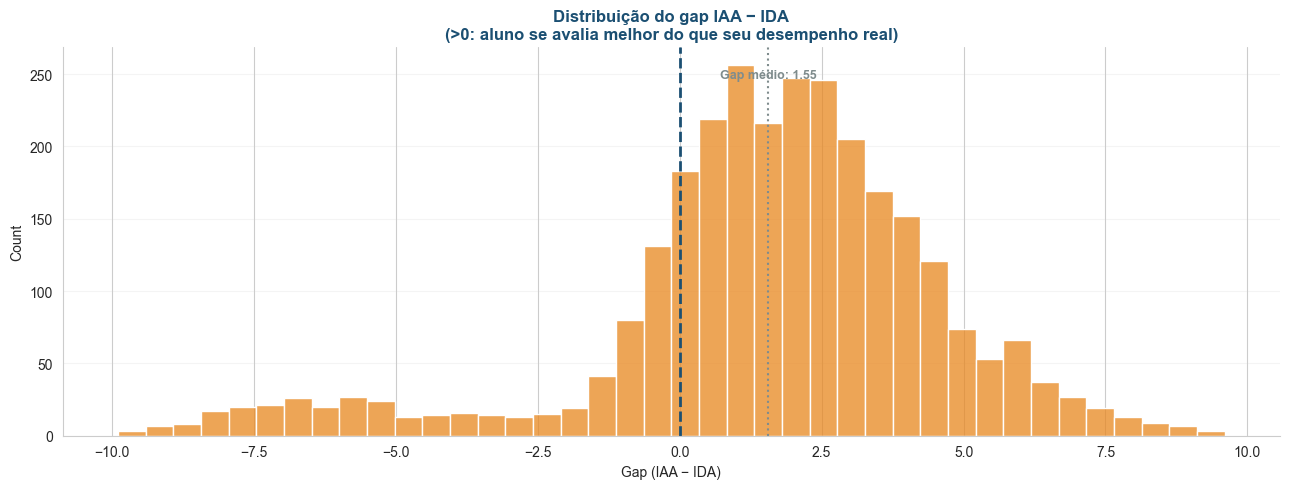

Gap médio (IAA - IDA): 1.55
% com superestimação (gap > 1): 61.5 %
% com subestimação (gap < -1): 10.8 %


In [36]:
CMAP_PM = LinearSegmentedColormap.from_list(
    "passos_magicos", [COR_CINZA, COR_AMARELO, COR_LARANJA, COR_AZUL], N=256
)

corr_iaa = df[["IAA", "IDA", "IEG"]].corr().round(2)
print(corr_iaa)

df["Gap_IAA_IDA"] = df["IAA"] - df["IDA"]

fig, ax = plt.subplots(figsize=(13, 5))
sns.histplot(df["Gap_IAA_IDA"].dropna(), bins=40, color=COR_LARANJA, ax=ax, edgecolor="white")
ax.axvline(0, color=COR_AZUL, linestyle="--", linewidth=2)
gap_medio = df["Gap_IAA_IDA"].mean()
ax.axvline(gap_medio, color=COR_CINZA, linestyle=":", linewidth=1.5)
ax.text(gap_medio, ax.get_ylim()[1]*0.92, f"Gap médio: {gap_medio:.2f}",
        ha="center", fontsize=9, color=COR_CINZA, fontweight="bold")

ax.set_title("Distribuição do gap IAA − IDA\n(>0: aluno se avalia melhor do que seu desempenho real)",
             fontsize=12, fontweight="bold", color=COR_AZUL)
ax.set_xlabel("Gap (IAA − IDA)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("../presentation/fig_q4a_gap_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gap médio (IAA - IDA):", gap_medio.round(2))
print("% com superestimação (gap > 1):", (df["Gap_IAA_IDA"] > 1).mean().round(3) * 100, "%")
print("% com subestimação (gap < -1):", (df["Gap_IAA_IDA"] < -1).mean().round(3) * 100, "%")


**Leitura:** a correlação entre IAA e desempenho real é **fraca** tanto com IDA (0,12) quanto com
IEG (0,13) — ou seja, a forma como o aluno se autoavalia praticamente não acompanha, de forma
linear, seu desempenho acadêmico nem seu engajamento observado. Isso fica evidente ao segmentar
por faixa de autoavaliação: alunos de alta, média e baixa autoavaliação apresentam IDA e IEG
médios muito próximos entre si. O gap IAA − IDA mostra uma parcela relevante de alunos com
superestimação (autoavaliação acima do desempenho real) e outra com subestimação — um padrão
compatível (mas não comprovado por este dado isolado) com contextos de vulnerabilidade social,
onde a percepção da própria capacidade pode estar desalinhada da realidade acadêmica por diversos
fatores externos. Recomenda-se tratar o gap como **hipótese de investigação psicopedagógica**,
não como diagnóstico — casos extremos (maior superestimação e maior subestimação) podem orientar
priorização de acompanhamento individualizado.

                      IDA   IEG
Faixa_IAA                      
Baixa autoavaliação  6.05  7.91
Média autoavaliação  6.44  8.32
Alta autoavaliação   6.64  8.47


C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\707797389.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo_iaa = df.groupby("Faixa_IAA")[["IDA", "IEG"]].mean().round(2)


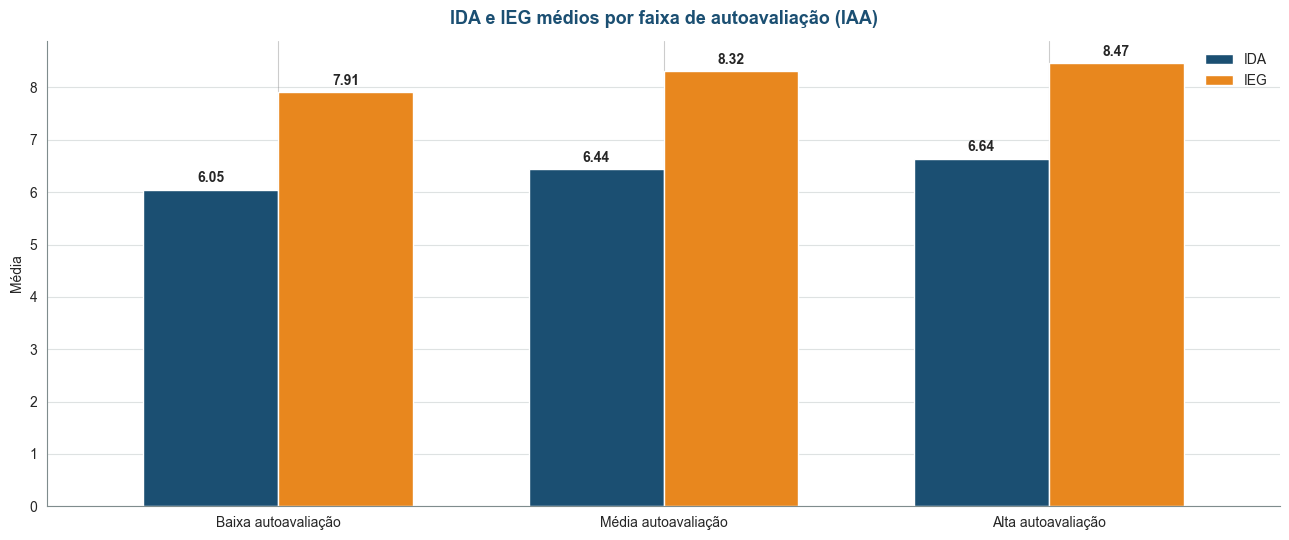

In [52]:
df["Faixa_IAA"] = pd.qcut(df["IAA"], q=3, labels=["Baixa autoavaliação", "Média autoavaliação", "Alta autoavaliação"])

resumo_iaa = df.groupby("Faixa_IAA")[["IDA", "IEG"]].mean().round(2)
print(resumo_iaa)

fig, ax = plt.subplots(figsize=(13, 5.5))
resumo_iaa.plot(kind="bar", ax=ax, color=[COR_AZUL, COR_LARANJA], width=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold", padding=3)

ax.set_title("IDA e IEG médios por faixa de autoavaliação (IAA)",
             fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Média")
ax.legend(title="", frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.25, color=COR_CINZA)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(COR_CINZA)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../presentation/fig_q4b_faixa_iaa.png", dpi=150, bbox_inches="tight")
plt.show()

Analisando casos extremos, de maior gap entre IAA e IDA:

In [31]:
extremos = pd.concat([
    df.nlargest(5, "Gap_IAA_IDA")[["RA", "Ano", "Fase_num", "IAA", "IDA", "Gap_IAA_IDA"]]
      .assign(Tipo="Maior superestimação"),
    df.nsmallest(5, "Gap_IAA_IDA")[["RA", "Ano", "Fase_num", "IAA", "IDA", "Gap_IAA_IDA"]]
      .assign(Tipo="Maior subestimação"),
])
print(extremos)

           RA   Ano  Fase_num    IAA  IDA  Gap_IAA_IDA                  Tipo
1305   RA-294  2022         3  9.600  0.0        9.600  Maior superestimação
437   RA-1229  2024         7  9.168  0.0        9.168  Maior superestimação
1254   RA-270  2024         7  9.168  0.0        9.168  Maior superestimação
583   RA-1311  2024         0  9.002  0.0        9.002  Maior superestimação
679   RA-1392  2024         0  9.002  0.0        9.002  Maior superestimação
1702   RA-456  2023         2  0.000  9.9       -9.900    Maior subestimação
50    RA-1024  2023         1  0.000  9.8       -9.800    Maior subestimação
2649   RA-819  2023         1  0.000  9.5       -9.500    Maior subestimação
2902   RA-935  2023         0  0.000  9.4       -9.400    Maior subestimação
2207   RA-651  2023         2  0.000  9.3       -9.300    Maior subestimação


## 5. Aspectos psicossociais (IPS) — padrões que antecedem quedas de desempenho/engajamento

**Pergunta:** Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?


**Leitura:** comparando o IPS do ano anterior entre alunos que caíram de IDA no ano seguinte e
os que não caíram, é possível avaliar se um IPS mais baixo antecede quedas de desempenho.
Se a mediana de IPS for visivelmente menor no grupo "com queda", isso sugere que fatores
psicossociais têm valor preditivo/de alerta precoce — reforçando a importância do
acompanhamento psicossocial contínuo (e alimentando a modelagem preditiva, pergunta 9).


In [60]:
painel = df.sort_values(["RA", "Ano"]).copy()
for col in ["IDA", "IEG", "IPS"]:
    painel[f"{col}_prev"] = painel.groupby("RA")[col].shift(1)
painel["Ano_prev"] = painel.groupby("RA")["Ano"].shift(1)

seq = painel[painel["Ano"] - painel["Ano_prev"] == 1].copy()
seq["Queda_IDA"] = seq["IDA"] < seq["IDA_prev"]
seq["Queda_IEG"] = seq["IEG"] < seq["IEG_prev"]

resumo_testes = []
for alvo in ["Queda_IDA", "Queda_IEG"]:
    g_sem = seq.loc[~seq[alvo], "IPS_prev"].dropna()
    g_com = seq.loc[seq[alvo], "IPS_prev"].dropna()
    stat, p = stats.mannwhitneyu(g_sem, g_com, alternative="greater")
    resumo_testes.append({
        "Alvo": alvo,
        "IPS médio (sem queda)": round(g_sem.mean(), 2), "n_sem": len(g_sem),
        "IPS médio (com queda)": round(g_com.mean(), 2), "n_com": len(g_com),
        "Diferença": round(g_sem.mean() - g_com.mean(), 2),
        "p-valor (Mann-Whitney)": round(p, 4),
    })
resumo_testes = pd.DataFrame(resumo_testes)
print(resumo_testes)

        Alvo  IPS médio (sem queda)  n_sem  IPS médio (com queda)  n_com  \
0  Queda_IDA                   6.06    630                   5.87    673   
1  Queda_IEG                   6.24    629                   5.70    674   

   Diferença  p-valor (Mann-Whitney)  
0       0.19                  0.1392  
1       0.55                  0.0003  


**Leitura:** comparando o IPS do ano anterior entre alunos com e sem queda no ano seguinte, os
resultados divergem conforme o indicador analisado. Para **desempenho acadêmico (IDA)**, a
diferença observada é pequena (6,06 vs. 5,87 pontos, Δ = 0,19) e **não estatisticamente
significativa** pelo teste de Mann-Whitney (p = 0,139) — não há evidência suficiente de que o IPS
do ano anterior, isoladamente, antecipe quedas de desempenho acadêmico. Já para **engajamento
(IEG)**, a diferença é maior (6,24 vs. 5,70 pontos, Δ = 0,55) e **estatisticamente significativa**
(p = 0,0003) — alunos que apresentam queda de engajamento no ano seguinte já tinham, em média, IPS
mais baixo no ano anterior.

Isso sugere que aspectos psicossociais funcionam como **sinal de alerta precoce mais para
engajamento do que para desempenho acadêmico propriamente dito** — o que é coerente com a
natureza do IPS (mede fatores relacionais e emocionais, mais próximos do envolvimento do aluno
com o programa do que do domínio de conteúdo em si). Reforça-se, portanto, o valor do
acompanhamento psicossocial contínuo como estratégia de prevenção de desengajamento, e sustenta o
uso do IPS como feature relevante na modelagem preditiva (pergunta 9) — com a ressalva de que seu
poder preditivo parece mais forte para engajamento futuro do que para desempenho futuro isolado.

C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\3699922621.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seq, x=alvo, y="IPS_prev", palette=[COR_AZUL, COR_LARANJA], ax=ax)
C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\3699922621.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sem queda", "Com queda"])
C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\3699922621.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seq, x=alvo, y="IPS_prev", palette=[COR_AZUL, COR_LARANJA], ax=ax)
C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\3699922621.py:

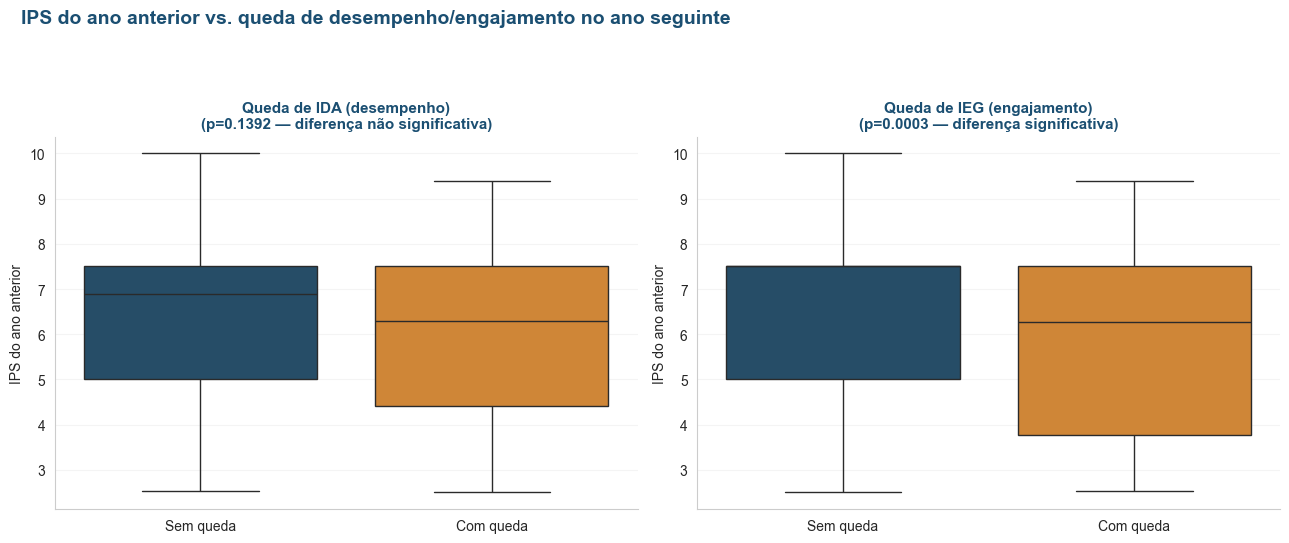

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("IPS do ano anterior vs. queda de desempenho/engajamento no ano seguinte",
             fontsize=14, fontweight="bold", color=COR_AZUL, x=0.02, ha="left")

for ax, alvo, titulo in zip(axes, ["Queda_IDA", "Queda_IEG"],
                             ["Queda de IDA (desempenho)", "Queda de IEG (engajamento)"]):
    sns.boxplot(data=seq, x=alvo, y="IPS_prev", palette=[COR_AZUL, COR_LARANJA], ax=ax)
    ax.set_xticklabels(["Sem queda", "Com queda"])
    ax.set_ylabel("IPS do ano anterior")
    ax.set_xlabel("")
    p_val = resumo_testes.loc[resumo_testes["Alvo"] == alvo, "p-valor (Mann-Whitney)"].iloc[0]
    sig = "diferença significativa" if p_val < 0.05 else "diferença não significativa"
    ax.set_title(f"{titulo}\n(p={p_val:.4f} — {sig})", fontsize=11, color=COR_AZUL)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("../presentation/fig_q5a_ips_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\2045782960.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_queda = seq.groupby("Faixa_IPS_prev")[["Queda_IDA", "Queda_IEG"]].mean().round(3) * 100


Taxa de queda (%) por faixa de IPS do ano anterior:
                 Queda_IDA  Queda_IEG
Faixa_IPS_prev                      
Baixo IPS            54.4       62.0
Médio IPS            48.3       41.4
Alto IPS             54.3       56.9


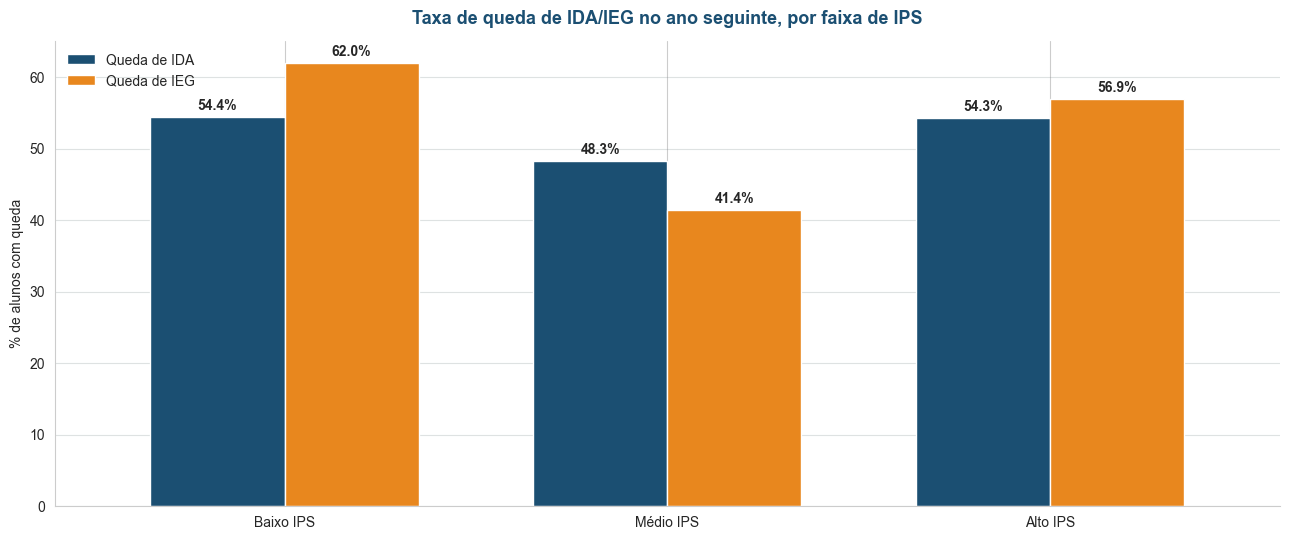

In [51]:
seq["Faixa_IPS_prev"] = pd.qcut(seq["IPS_prev"], q=3, labels=["Baixo IPS", "Médio IPS", "Alto IPS"])

taxa_queda = seq.groupby("Faixa_IPS_prev")[["Queda_IDA", "Queda_IEG"]].mean().round(3) * 100
print("Taxa de queda (%) por faixa de IPS do ano anterior:\n", taxa_queda)

fig, ax = plt.subplots(figsize=(13, 5.5))
taxa_queda.plot(kind="bar", ax=ax, color=[COR_AZUL, COR_LARANJA], width=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=10, fontweight="bold", padding=3)
ax.set_title("Taxa de queda de IDA/IEG no ano seguinte, por faixa de IPS",
             fontsize=13, fontweight="bold", color=COR_AZUL, pad=12)
ax.set_ylabel("% de alunos com queda")
ax.set_xlabel("")
ax.legend(["Queda de IDA", "Queda de IEG"], frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.25, color=COR_CINZA)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../presentation/fig_q5b_taxa_queda_faixa_ips.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Avaliações psicopedagógicas (IPP) x defasagem identificada pelo IAN

**Pergunta:** As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?


In [47]:
ORDEM_CAT = ["Severa", "Moderada", "Em fase"]

df_q6 = df.dropna(subset=["Categoria_Defasagem", "IPP"]).copy()

resumo_ipp = df_q6.groupby("Categoria_Defasagem")["IPP"].agg(["mean", "median", "count"]).round(2)
resumo_ipp = resumo_ipp.reindex(ORDEM_CAT)
print(resumo_ipp)

grupos = [df_q6.loc[df_q6["Categoria_Defasagem"] == cat, "IPP"] for cat in ORDEM_CAT]
h_stat, p_kw = stats.kruskal(*grupos)
corr_spearman = df[["IPP", "IAN"]].corr(method="spearman").iloc[0, 1].round(2)

print(f"\nKruskal-Wallis: H={h_stat:.2f}, p={p_kw:.4f}")
print(f"Correlação Spearman IPP x IAN: {corr_spearman}")

                     mean  median  count
Categoria_Defasagem                     
Severa               7.01    7.50     17
Moderada             7.46    7.50   1067
Em fase              7.68    7.71    908

Kruskal-Wallis: H=34.72, p=0.0000
Correlação Spearman IPP x IAN: 0.13


**Leitura:** o teste de Kruskal-Wallis indica diferença estatisticamente significativa de IPP
entre as categorias de defasagem (H=34,72; p<0,0001), e a mediana de IPP de fato cresce da
categoria "Severa" (7,50) para "Em fase" (7,71) — uma direção consistente com o esperado, em que
maior defasagem tende a se associar a avaliação psicopedagógica mais baixa. No entanto, a
correlação de Spearman entre IPP e IAN é **fraca** (0,13), e a diferença entre as medianas das
categorias "Moderada" (7,50) e "Em fase" (7,71) é pequena — o que indica que o IPP não discrimina
fortemente entre níveis de defasagem na prática, mesmo com a diferença sendo estatisticamente
significativa. Vale notar ainda que a categoria "Severa" tem apenas 17 alunos, uma amostra muito
pequena frente aos demais grupos (1.067 e 908), o que limita a confiabilidade de conclusões
específicas sobre esse grupo.

Em conjunto, os resultados sugerem que IPP e IAN são **parcialmente consistentes, mas não
redundantes** — ambos captam, em alguma medida, a mesma direção de vulnerabilidade educacional,
porém cada instrumento parece capturar uma dimensão distinta do aluno (uma avaliação qualitativa
e uma métrica de defasagem de fase). Isso reforça o valor de manter os dois indicadores na
modelagem preditiva (pergunta 9) como fontes de informação complementares, em vez de tratar um
como substituto do outro.

C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\1227199638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q6, x="Categoria_Defasagem", y="IPP", order=ORDEM_CAT, palette=PALETA, ax=ax)
C:\Users\João Braga\AppData\Local\Temp\ipykernel_14344\1227199638.py:2: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(data=df_q6, x="Categoria_Defasagem", y="IPP", order=ORDEM_CAT, palette=PALETA, ax=ax)


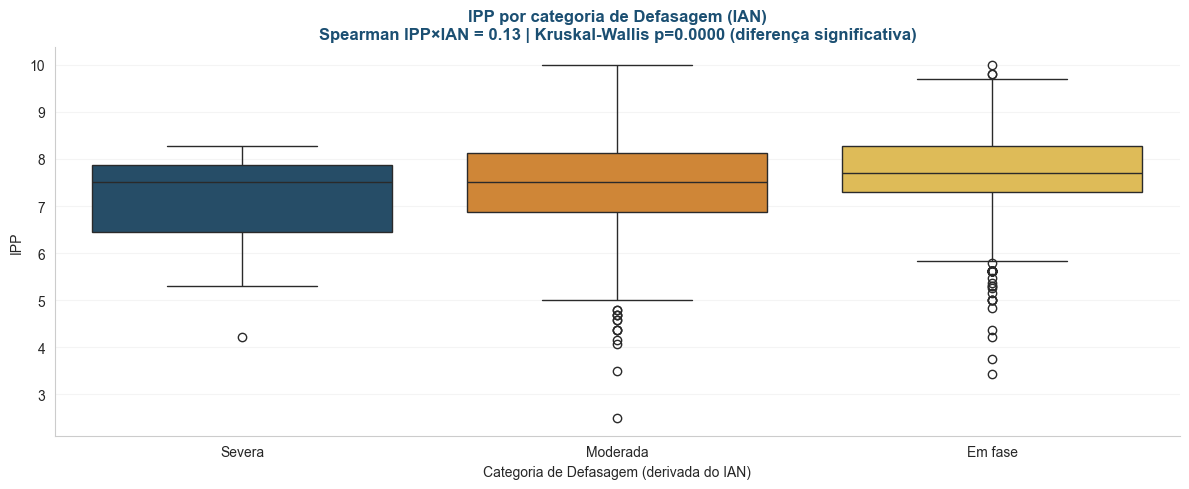

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_q6, x="Categoria_Defasagem", y="IPP", order=ORDEM_CAT, palette=PALETA, ax=ax)

sig = "diferença significativa" if p_kw < 0.05 else "diferença não significativa"
ax.set_title(f"IPP por categoria de Defasagem (IAN)\n"
             f"Spearman IPP×IAN = {corr_spearman} | Kruskal-Wallis p={p_kw:.4f} ({sig})",
             fontsize=12, color=COR_AZUL, fontweight="bold")
ax.set_xlabel("Categoria de Defasagem (derivada do IAN)")
ax.set_ylabel("IPP")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("../presentation/fig_q6_ipp.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** O boxplot mostra a distribuição de IPP em cada categoria de defasagem, com medianas crescendo de
"Severa" para "Em fase" — direção esperada, mas com sobreposição considerável entre as caixas,
refletindo a correlação fraca (Spearman = 0,13) e a diferença modesta entre "Moderada" e "Em fase", conforme
comentado anteriormente. O grupo "Severa" tem amostra pequena (n=17), o que também explica sua caixa mais 
estreita e volátil.

## 7. Ponto de Virada (IPV) — quais comportamentos mais influenciam?

**Pergunta:** Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?


In [71]:
indicadores = ["IDA", "IEG", "IAA", "IPS", "IPP", "IAN"]
indicadores_sem_ipp = [c for c in indicadores if c != "IPP"]

# Correlação sem IPP, para os 3 anos (2022, 2023, 2024)
df_sem_ipp = df.dropna(subset=indicadores_sem_ipp + ["IPV"]).copy()
corr_sem_ipp = (
    df_sem_ipp.groupby("Ano")[indicadores_sem_ipp + ["IPV"]]
    .apply(lambda g: g.corr()["IPV"].drop("IPV"))
)

# Correlação do IPP isoladamente, só onde ele existe (2023 e 2024)
df_ipp = df.dropna(subset=["IPP", "IPV"]).copy()
corr_ipp = (
    df_ipp.groupby("Ano")[["IPP", "IPV"]]
    .apply(lambda g: g.corr()["IPV"].drop("IPV"))
)

# Junta os dois: IPP fica NaN em 2022, preenchido em 2023/2024
corr_por_ano = corr_sem_ipp.join(corr_ipp, how="left")[indicadores]
print("Correlação com IPV, por ano:\n", corr_por_ano.round(3))

Correlação com IPV, por ano:
 IPV     IDA    IEG    IAA    IPS    IPP    IAN
Ano                                           
2022  0.617  0.589  0.256  0.208    NaN  0.111
2023  0.542  0.448  0.139  0.077  0.516  0.143
2024  0.514  0.535  0.148  0.105  0.750  0.185


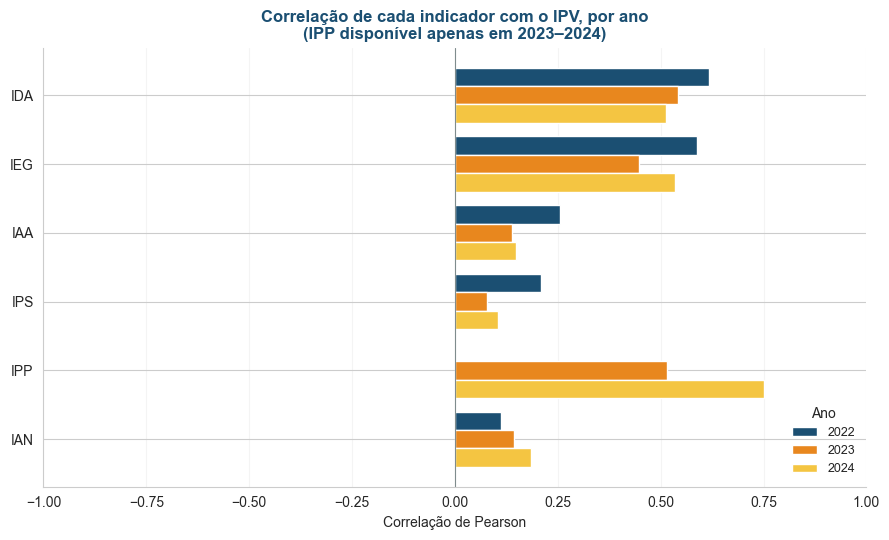

In [72]:
fig, ax = plt.subplots(figsize=(9, 5.5))

corr_por_ano_t = corr_por_ano.T  # index=indicadores, colunas=Ano

y_pos = np.arange(len(indicadores))
n_anos = len(corr_por_ano_t.columns)
altura_barra = 0.8 / n_anos

for i, (ano, cor) in enumerate(zip(corr_por_ano_t.columns, PALETA)):
    offset = (i - (n_anos - 1) / 2) * altura_barra
    valores = corr_por_ano_t[ano]  # NaN vira barra "ausente" automaticamente
    ax.barh(y_pos + offset, valores, height=altura_barra, color=cor, label=str(ano))

ax.set_yticks(y_pos)
ax.set_yticklabels(indicadores)
ax.axvline(0, color=COR_CINZA, linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_title("Correlação de cada indicador com o IPV, por ano\n(IPP disponível apenas em 2023–2024)",
             fontsize=12, color=COR_AZUL, fontweight="bold")
ax.set_xlabel("Correlação de Pearson")
ax.set_ylabel("")
ax.legend(title="Ano", frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../presentation/fig_q7_ipv_por_ano.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** em 2022 e 2023, IDA (desempenho acadêmico) e IEG (engajamento) lideram como os
indicadores mais associados ao IPV (correlações entre 0,44 e 0,62), mantendo um padrão consistente
com o observado na análise geral, o que é um insight acionável: reforçar engajamento pode ser uma
alavanca mais direta para o ponto de virada do que fatores puramente emocionais. Em 2024, no entanto,
o cenário muda: a correlação entre IPP (avaliação psicopedagógica) e IPV salta de 0,516 (2023) para
**0,750** — a correlação mais alta registrada em toda a série, superando inclusive IDA e IEG naquele ano.
Como o IPP só está disponível a partir de 2023, ainda não é possível afirmar se esse salto representa
uma tendência consolidada ou uma oscilação pontual de uma janela de apenas dois anos; ainda assim, é um
sinal relevante de que a avaliação psicopedagógica pode estar ganhando peso como fator associado ao
ponto de virada nos anos mais recentes do programa.

IAA (autoavaliação) e IPS (psicossocial) apresentam correlação consistentemente fraca em todos os
anos, com queda notável de 2022 (0,26 e 0,21) para 2023-2024 (abaixo de 0,15) — reforçando o
achado da pergunta 4, de que a autoavaliação do aluno tende a não acompanhar de perto seus
resultados observáveis. O IAN se mantém fraco e estável ao longo de todo o período (0,11 a 0,19).

Vale reforçar que essa é uma leitura de **correlação simples**, sujeita à multicolinearidade entre
os próprios indicadores (como visto na análise geral acima); a visão de influência controlada por
regressão múltipla é a mais adequada para afirmar qual fator, isoladamente, mais pesa sobre o IPV
— e o crescimento do IPP em 2024 é um candidato natural para investigar com mais atenção nessa
análise controlada.

## 8. Multidimensionalidade — quais combinações de indicadores mais elevam o INDE?

**Pergunta:** Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?


R² do modelo linear (explicativo, não preditivo): 0.978

Peso de cada indicador sobre o INDE (coeficiente padronizado aproximado):
IEG    0.236
IDA    0.225
IPP    0.200
IAN    0.103
IAA    0.097
IPS    0.091
dtype: float64


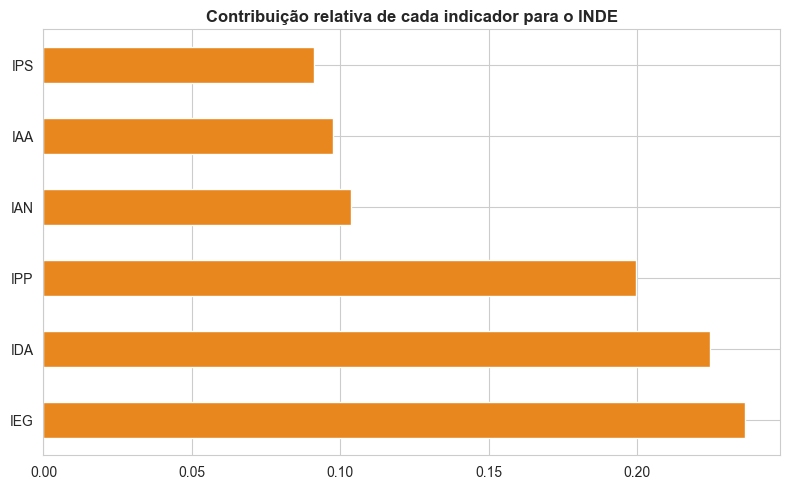

In [9]:

from sklearn.linear_model import LinearRegression

cols_x = ["IDA", "IEG", "IPS", "IPP", "IAA", "IAN"]
sub = df.dropna(subset=cols_x + ["INDE"])

X = sub[cols_x]
y = sub["INDE"]
reg = LinearRegression().fit(X, y)

coef = pd.Series(reg.coef_, index=cols_x).sort_values(ascending=False)
print("R² do modelo linear (explicativo, não preditivo):", round(reg.score(X, y), 3))
print("\nPeso de cada indicador sobre o INDE (coeficiente padronizado aproximado):")
print(coef.round(3))

fig, ax = plt.subplots(figsize=(8,5))
coef.plot(kind="barh", color=COR_LARANJA, ax=ax)
ax.set_title("Contribuição relativa de cada indicador para o INDE")
plt.tight_layout()
plt.savefig("../presentation/fig_q8_inde.png", dpi=150, bbox_inches="tight")
plt.show()


**Leitura:** os coeficientes mostram qual combinação de indicadores tem maior peso estatístico
sobre o INDE. Isso ajuda a Passos Mágicos a priorizar frentes de atuação (ex.: se IDA e IEG têm os
maiores pesos, investir em reforço acadêmico + estratégias de engajamento tende a ter o maior
retorno sobre a nota geral do aluno).


## 9. Previsão de risco de defasagem (Machine Learning)

**Pergunta:** Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

➡️ O desenvolvimento completo do modelo preditivo (feature engineering, split treino/teste,
modelagem, avaliação de métricas) está no notebook **`03_predictive_model.ipynb`**, dedicado
exclusivamente a essa entrega. Aqui deixamos apenas a definição do problema:

- **Variável-alvo:** aluno entra em risco de defasagem (`Categoria_Defasagem` piora ou
  `Defasagem <= -1`) no ano seguinte.
- **Features candidatas:** IAN, IDA, IEG, IAA, IPS, IPP, IPV do ano corrente/anterior, Fase,
  Anos na PM, Idade, Indicado a bolsa.


## 10. Efetividade do programa por fase (Pedra)

**Pergunta:** Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista, Topázio)?


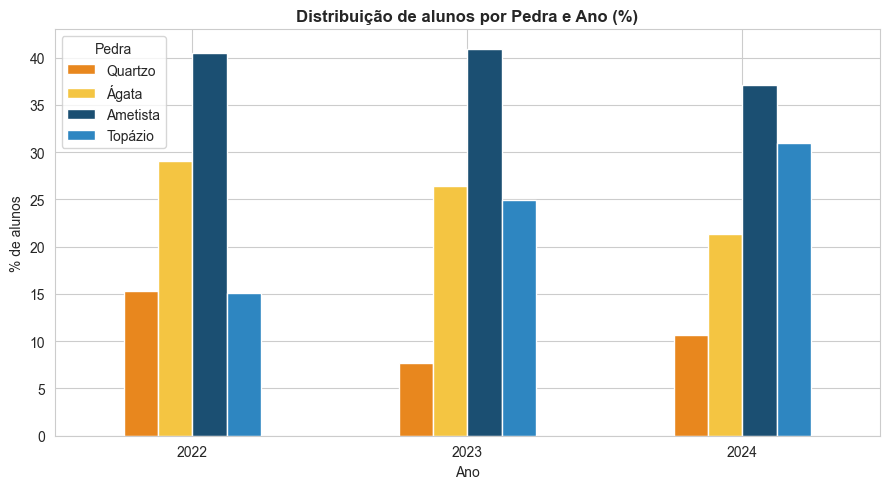

Pedra  Quartzo  Ágata  Ametista  Topázio
Ano                                     
2022      15.3   29.1      40.5     15.1
2023       7.7   26.4      40.9     24.9
2024      10.6   21.3      37.1     30.9

% de alunos que subiram, mantiveram ou desceram de Pedra (ano a ano):
Evolucao
Manteve    50.6
Desceu     25.1
Subiu      24.4
Name: proportion, dtype: float64


In [7]:

ordem_pedra = ["Quartzo", "Ágata", "Ametista", "Topázio"]
pedra_ano = pd.crosstab(df["Ano"], df["Pedra"], normalize="index")[ordem_pedra] * 100

fig, ax = plt.subplots(figsize=(9,5))
pedra_ano.plot(kind="bar", ax=ax, color=[COR_LARANJA, COR_AMARELO, COR_AZUL, "#2E86C1"])
ax.set_title("Distribuição de alunos por Pedra e Ano (%)")
ax.set_ylabel("% de alunos")
ax.legend(title="Pedra")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../presentation/fig_q10_pedra.png", dpi=150, bbox_inches="tight")
plt.show()

print(pedra_ano.round(1))

# Transições de pedra ano a ano (para quem tem 2+ anos)
painel2 = df.sort_values(["RA","Ano"]).copy()
painel2["Pedra_prev"] = painel2.groupby("RA")["Pedra"].shift(1)
trans = painel2.dropna(subset=["Pedra","Pedra_prev"])
mapa_pedra = {p:i for i,p in enumerate(ordem_pedra)}
trans = trans[trans["Pedra"].isin(ordem_pedra) & trans["Pedra_prev"].isin(ordem_pedra)]
trans["Evolucao"] = trans["Pedra"].map(mapa_pedra) - trans["Pedra_prev"].map(mapa_pedra)
print("\n% de alunos que subiram, mantiveram ou desceram de Pedra (ano a ano):")
print((trans["Evolucao"].apply(lambda x: "Subiu" if x>0 else ("Desceu" if x<0 else "Manteve"))
       .value_counts(normalize=True)*100).round(1))


**Leitura:** a distribuição de Pedras ao longo dos anos mostra se a proporção de alunos em
Topázio/Ametista (mais avançados) está crescendo e a de Quartzo caindo — indicando efetividade
real do programa. A análise de transições (subiu/manteve/desceu) complementa isso, mostrando a
mobilidade individual dos alunos entre as classificações, e não apenas o retrato agregado.


In [8]:
from statsmodels.stats.proportion import proportions_ztest

n_subiu = (trans["Evolucao"] > 0).sum()
n_desceu = (trans["Evolucao"] < 0).sum()
n_total_mudou = n_subiu + n_desceu

stat, p_val = proportions_ztest(count=n_subiu, nobs=n_total_mudou, value=0.5)
print(f"Subiu: {n_subiu} | Desceu: {n_desceu} | p-valor (subiu != metade das mudanças): {p_val:.4f}")

# Composição da amostra por ano — checa se há muita entrada/saída de alunos
alunos_por_ano = df.groupby("Ano")["RA"].nunique()
print("\nAlunos únicos por ano:\n", alunos_por_ano)

ras_2022 = set(df.loc[df["Ano"]==2022, "RA"])
ras_2024 = set(df.loc[df["Ano"]==2024, "RA"])
print(f"\nAlunos presentes em 2022 E 2024 (mesma coorte): {len(ras_2022 & ras_2024)}")
print(f"Alunos só em 2022 (saíram): {len(ras_2022 - ras_2024)}")
print(f"Alunos só em 2024 (novos): {len(ras_2024 - ras_2022)}")

Subiu: 305 | Desceu: 314 | p-valor (subiu != metade das mudanças): 0.7175

Alunos únicos por ano:
 Ano
2022     860
2023    1014
2024    1156
Name: RA, dtype: int64

Alunos presentes em 2022 E 2024 (mesma coorte): 472
Alunos só em 2022 (saíram): 388
Alunos só em 2024 (novos): 684


**Leitura:** a distribuição de Pedras mostra um sinal positivo claro para Topázio, que cresce de
forma consistente ao longo dos três anos (15,1% → 24,9% → 30,9%), quase dobrando sua participação
— o indicador mais forte de efetividade nesta análise. Ágata, por outro lado, cai de forma
consistente (29,1% → 21,3%), e Quartzo não segue um padrão linear: cai de 2022 para 2023, mas volta
a subir em 2024 (15,3% → 7,7% → 10,6%) — o que contraria uma leitura de "melhora consistente e
uniforme" em todas as categorias.

A análise de transições individuais reforça a necessidade de cautela: apenas 24,4% dos alunos
**subiram** de Pedra de um ano para o outro, praticamente empatado com os 25,1% que **desceram** —
e 50,6% mantiveram a mesma classificação. Ou seja, no nível individual, a evolução está longe de
ser unidirecional: para cada aluno que avança, há quase um aluno que retrocede.

Essa aparente contradição entre a visão agregada (melhora no perfil geral) e a visão individual
(mobilidade equilibrada entre subir e descer) sugere que parte do ganho observado na distribuição
por Pedra pode estar relacionada à **composição da amostra** ao longo dos anos (entrada de novos
alunos, saída de outros), e não apenas à evolução constante dos mesmos alunos dentro do programa.
Portanto, os dados **não permitem afirmar que há melhora consistente e generalizada** — o achado
mais robusto é o crescimento de Topázio, mas a mobilidade individual mista indica que o impacto do
programa é heterogêneo entre os alunos, não uniforme.

## 11. Insights adicionais

- Diferenças por tipo de instituição de ensino (pública x Rede Decisão).


In [38]:
print("Instituição de ensino — alunos únicos:")
print(df.groupby("Instituicao_ensino")["RA"].nunique())

Instituição de ensino — alunos únicos:
Instituicao_ensino
Bolsista Universitário *Formado (a)            13
Concluiu o 3º EM                               12
Escola JP II                                    2
Escola Pública                                752
Nenhuma das opções acima                        2
Privada                                        86
Privada *Parcerias com Bolsa 100%              81
Privada - Pagamento por *Empresa Parceira      13
Privada - Programa de Apadrinhamento          121
Privada - Programa de apadrinhamento            1
Pública                                      1173
Rede Decisão                                  106
Name: RA, dtype: int64


In [39]:
risco_inst = pd.crosstab(df["Instituicao_ensino"], df["Categoria_Defasagem"], normalize="index").round(3) * 100

print("\nDistribuição de risco por Instituição (%):\n", risco_inst)


Distribuição de risco por Instituição (%):
 Categoria_Defasagem                        Em fase  Moderada  Severa
Instituicao_ensino                                                  
Bolsista Universitário *Formado (a)          100.0       0.0     0.0
Concluiu o 3º EM                              28.6      71.4     0.0
Escola JP II                                   0.0     100.0     0.0
Escola Pública                                26.3      70.5     3.2
Nenhuma das opções acima                       0.0     100.0     0.0
Privada                                       74.0      26.0     0.0
Privada *Parcerias com Bolsa 100%             99.0       1.0     0.0
Privada - Pagamento por *Empresa Parceira    100.0       0.0     0.0
Privada - Programa de Apadrinhamento          78.4      21.6     0.0
Privada - Programa de apadrinhamento           0.0     100.0     0.0
Pública                                       41.8      57.2     1.0
Rede Decisão                                  57.5      38

- Diferenças por gênero nos indicadores.

In [40]:
print("\nGênero — alunos únicos:")
print(df.groupby("Genero")["RA"].nunique())


Gênero — alunos únicos:
Genero
Feminino     899
Masculino    774
Name: RA, dtype: int64


In [44]:
risco_genero = pd.crosstab(df["Genero"], df["Categoria_Defasagem"], normalize="index").round(3) * 100

print("Distribuição de risco por Gênero (%):\n", risco_genero)

Distribuição de risco por Gênero (%):
 Categoria_Defasagem  Em fase  Moderada  Severa
Genero                                        
Feminino                47.0      51.5     1.4
Masculino               41.2      57.3     1.6


- Relação entre tempo de permanência na Passos Mágicos (Anos_na_PM) e evolução do INDE.

In [42]:
print("\nAnos na PM — distribuição de alunos (linhas do painel, não únicos, já que Anos_na_PM varia por ano):")
print(df["Anos_na_PM"].value_counts().sort_index())


Anos na PM — distribuição de alunos (linhas do painel, não únicos, já que Anos_na_PM varia por ano):
Anos_na_PM
0.0    1117
1.0     654
2.0     399
3.0     524
4.0     165
5.0      86
6.0      61
7.0      24
Name: count, dtype: int64


In [46]:
risco_anos_pm = pd.crosstab(df["Anos_na_PM"], df["Categoria_Defasagem"], normalize="index").round(3) * 100

print("Distribuição de risco por Anos_na_PM (%):\n", risco_anos_pm)

Distribuição de risco por Anos_na_PM (%):
 Categoria_Defasagem  Em fase  Moderada  Severa
Anos_na_PM                                    
0.0                     39.9      58.5     1.6
1.0                     35.0      63.8     1.2
2.0                     52.6      47.1     0.3
3.0                     60.7      37.4     1.9
4.0                     40.6      58.2     1.2
5.0                     44.2      52.3     3.5
6.0                     39.3      55.7     4.9
7.0                     45.8      54.2     0.0


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


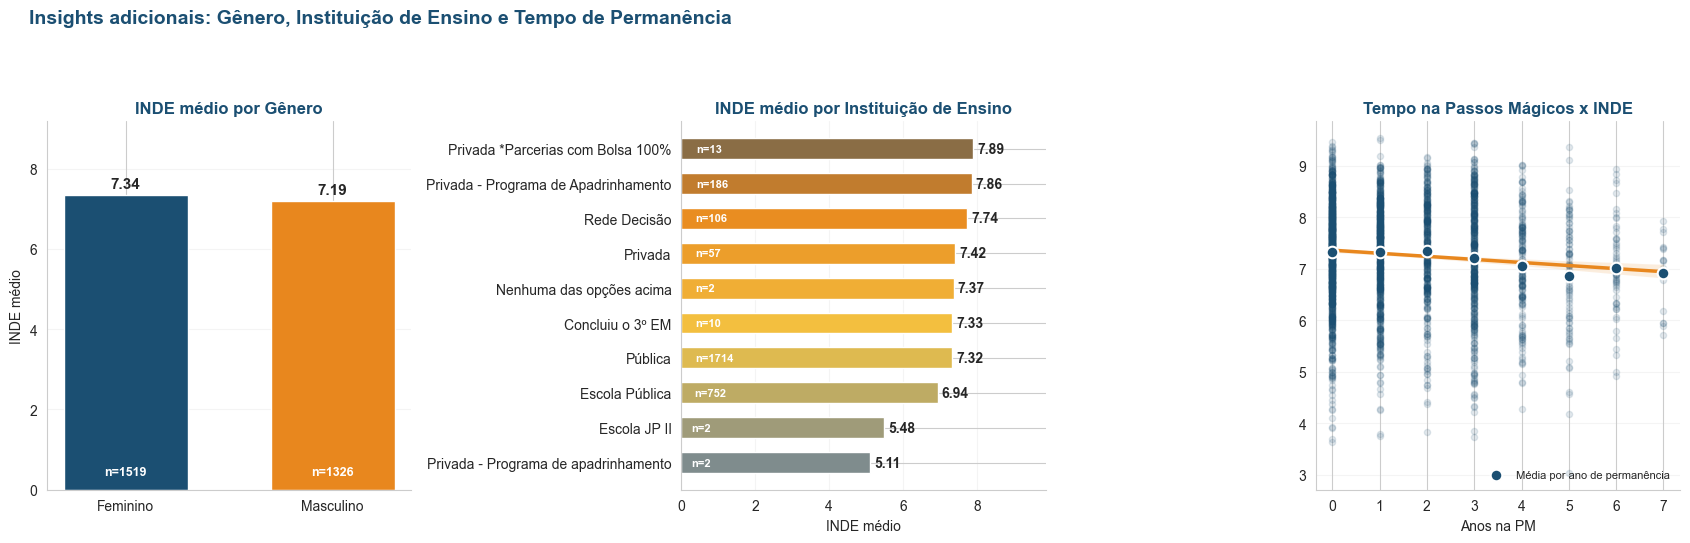

In [43]:
CMAP_PM = LinearSegmentedColormap.from_list(
    "passos_magicos", [COR_CINZA, COR_AMARELO, COR_LARANJA, COR_AZUL], N=256
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle("Insights adicionais: Gênero, Instituição de Ensino e Tempo de Permanência",
             fontsize=14, fontweight="bold", color=COR_AZUL, x=0.02, ha="left")

# --- Painel 1: INDE médio por Gênero, com n e rótulos ---
resumo_genero = df.groupby("Genero")["INDE"].agg(["mean", "count"]).round(2)
bars = axes[0].bar(resumo_genero.index, resumo_genero["mean"], color=[COR_AZUL, COR_LARANJA], width=0.6)
axes[0].bar_label(bars, fmt="%.2f", fontsize=11, fontweight="bold", padding=3)
for i, (idx, row) in enumerate(resumo_genero.iterrows()):
    axes[0].text(i, row["mean"] * 0.05, f"n={int(row['count'])}", ha="center",
                 fontsize=9, color="white", fontweight="bold")
axes[0].set_title("INDE médio por Gênero", fontsize=12, color=COR_AZUL, fontweight="bold")
axes[0].set_ylabel("INDE médio")
axes[0].set_ylim(0, resumo_genero["mean"].max() * 1.25)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", alpha=0.2)
axes[0].tick_params(axis="x", rotation=0)

# --- Painel 2: INDE médio por Instituição, em barras horizontais (resolve sobreposição de rótulos) ---
resumo_inst = df.groupby("Instituicao_ensino")["INDE"].agg(["mean", "count"]).round(2).sort_values("mean")
cores_inst = [CMAP_PM(i / max(len(resumo_inst) - 1, 1)) for i in range(len(resumo_inst))]

bars2 = axes[1].barh(resumo_inst.index, resumo_inst["mean"], color=cores_inst, height=0.6)
axes[1].bar_label(bars2, fmt="%.2f", fontsize=10, fontweight="bold", padding=3)
for i, (idx, row) in enumerate(resumo_inst.iterrows()):
    axes[1].text(row["mean"] * 0.05, i, f"n={int(row['count'])}", va="center",
                 fontsize=8, color="white", fontweight="bold")

axes[1].set_title("INDE médio por Instituição de Ensino", fontsize=12, color=COR_AZUL, fontweight="bold")
axes[1].set_xlabel("INDE médio")
axes[1].set_ylabel("")
axes[1].set_xlim(0, resumo_inst["mean"].max() * 1.25)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="x", alpha=0.2)

# --- Painel 3: Anos na PM x INDE — regplot + médias por faixa sobrepostas ---
sns.regplot(data=df, x="Anos_na_PM", y="INDE", scatter_kws={"alpha": 0.12, "color": COR_AZUL, "s": 20},
            line_kws={"color": COR_LARANJA, "linewidth": 2.5}, ax=axes[2])

medias_por_ano_pm = df.groupby("Anos_na_PM")["INDE"].mean()
axes[2].scatter(medias_por_ano_pm.index, medias_por_ano_pm.values,
                 color=COR_AZUL, s=70, zorder=5, edgecolor="white", linewidth=1.5,
                 label="Média por ano de permanência")
axes[2].legend(fontsize=8, frameon=False, loc="lower right")
axes[2].set_title("Tempo na Passos Mágicos x INDE", fontsize=12, color=COR_AZUL, fontweight="bold")
axes[2].set_xlabel("Anos na PM")
axes[2].set_ylabel("")
axes[2].spines[["top", "right"]].set_visible(False)
axes[2].grid(axis="y", alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("../presentation/fig_q11_insights.png", dpi=150, bbox_inches="tight")
plt.show()

**Sugestões para a Passos Mágicos**
- Priorizar acompanhamento reforçado para alunos com **gap alto entre IAA e IDA** (podem estar
  subestimando/superestimando sua evolução real).
- IEG e IPS (do ano anterior) seguem como as alavancas operacionais mais diretas, visto sua forte relação com IPV e INDE — engajamento
  previsível e sinal de alerta psicossocial, respectivamente — já discutidos em detalhe nas perguntas
  3, 5 e 7.
- Monitorar o IPS do ano anterior como sinal de alerta precoce para risco de queda de desempenho.
- Alunos vindos de escola pública (Escola Pública e Pública) apresentam taxas de defasagem (Moderada + Severa) entre 58% e 74%, contra 26%
  ou menos entre alunos de escolas privadas — incluindo os que têm bolsa 100% (apenas 1% Moderada, 0% Severa). Isso reforça que a origem escolar
  é um forte marcador de vulnerabilidade e pode orientar priorização de recursos e acompanhamento mais próximo logo na entrada do aluno no
  programa, antes mesmo de qualquer indicador comportamental se manifestar.

- Diversas categorias de instituição de ensino têm menos de 15 alunos — qualquer leitura sobre elas deve ser tratada como anedótica, não como padrão
  populacional. O mesmo vale para as faixas mais altas de tempo de permanência (5+ anos), onde a amostra cai
  para menos de 90 alunos por faixa.
